# Loan Prediction Analysis using Machine Learning

# Introduction

The purpose of this project is to build a machine learning model that predicts whether a loan application will be approved or not.

The project uses Logistic Regression for classification and includes data cleaning, visualization, model training, and evaluation.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Check Dataset File
First, we confirm that the dataset file exists in the notebook folder.

In [30]:
print("Files in current folder:")
print(os.listdir())

Files in current folder:
['.cache', '.copilot', '.dotnet', '.idlerc', '.ipynb_checkpoints', '.ipython', '.matplotlib', '.nuget', '.platformio', '.templateengine', '.vscode', '.vscode-shared', '2.0', '3D Objects', 'AppData', 'Application Data', 'citesmart', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'loan-prediction-dataset.csv', 'loan-prediction-dataset.ipynb', 'Local Settings', 'MicrosoftEdgeBackups', 'Music', 'My Documents', 'NetHood', 'New folder', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{b7532662-0b6c-11f1-bcb4-caef04f235c2}.TM.blf', 'NTUSER.DAT{b7532662-0b6c-11f1-bcb4-caef04f235c2}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{b7532662-0b6c-11f1-bcb4-caef04f235c2}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'source', 'Start Menu', 'Task 1 Iris Dataset.ipynb', 'Templates', 'This PC - Sh

## Load Dataset

We load the dataset using pandas and inspect its structure.

In [31]:
# Load dataset
df = pd.read_csv("loan-prediction-dataset.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural      

## Dataset Overview

We check shape, columns, first rows, and missing values.

In [32]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (614, 13)

Columns:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

First 5 Rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583

## Data Cleaning

We handle missing values:
- Categorical → filled with mode
- Numerical → filled with median

In [33]:
# Select categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

# Fill missing categorical values
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Select numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Fill missing numerical values
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_15792\3072562855.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


## Loan Amount Distribution

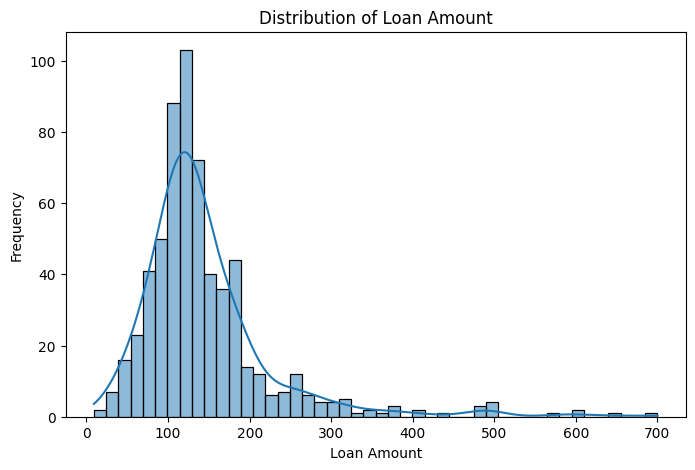

In [34]:
# Check if LoanAmount column exists
if "LoanAmount" in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df["LoanAmount"], kde=True)

    plt.title("Distribution of Loan Amount")
    plt.xlabel("Loan Amount")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("LoanAmount column not found in dataset.")

## Education Distribution

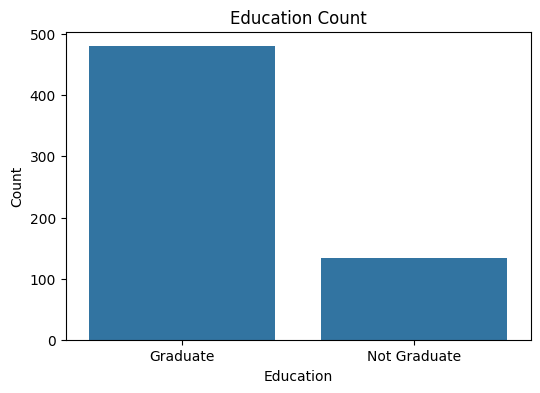

In [35]:
# Check if Education column exists
if "Education" in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x="Education")

    plt.title("Education Count")
    plt.xlabel("Education")
    plt.ylabel("Count")
    plt.show()
else:
    print("Education column not found in dataset.")

## Applicant Income Distribution

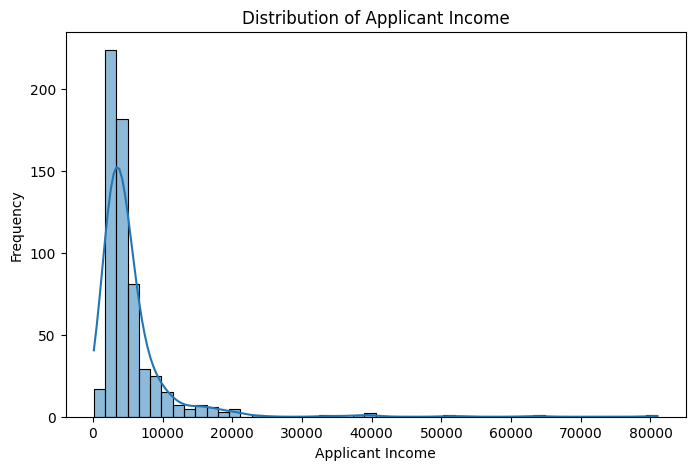

In [36]:
# Check if ApplicantIncome column exists
if "ApplicantIncome" in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df["ApplicantIncome"], kde=True)

    plt.title("Distribution of Applicant Income")
    plt.xlabel("Applicant Income")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("ApplicantIncome column not found in dataset.")

## Encoding Categorical Data

We convert text data into numbers using Label Encoding.

In [37]:
encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

## Feature Selection

We separate features (X) and target variable (y).

In [38]:
# Check target column
if "Loan_Status" in df.columns:
    X = df.drop("Loan_Status", axis=1)
    y = df["Loan_Status"]
else:
    raise ValueError("Loan_Status column not found in dataset.")

# Remove Loan_ID if present
if "Loan_ID" in X.columns:
    X = X.drop("Loan_ID", axis=1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (614, 11)
Target shape: (614,)


## Train Test Split

Dataset is split into training and testing sets.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (491, 11)
Testing data shape: (123, 11)


## Logistic Regression Model Training

In [40]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Model Prediction

In [41]:
y_pred = model.predict(X_test)
print("Predictions completed!")

Predictions completed!


## Model Evaluation
We evaluate model performance using accuracy, confusion matrix, and classification report.

In [42]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7886178861788617

Confusion Matrix:
[[18 25]
 [ 1 79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



## Confusion Matrix Visualization

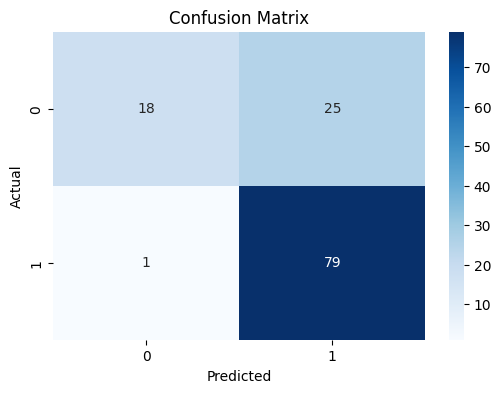

In [43]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Conclusion

In this project, we built a Logistic Regression model to predict loan approval.

- Data was cleaned and preprocessed
- Visualizations helped understand patterns
- Model was trained and evaluated successfully

This project demonstrates a basic machine learning classification workflow.